## Star formation yellowbal PCA

### Alex Emert

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from plotnine import *
from pyhere import here
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from ratio_function import RatioGenerator
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn import set_config

# make it work with data frames
set_config(transform_output="pandas")


In [13]:
phot = pd.read_csv(here("data/cleaned", "MIRION_cleaned_everything.csv"))
phot=phot.drop(columns=['LRATIO', 'T_BOL', 'LM', 'L_BOL', 'MASS', 'DIAM', 'SURF_DENS', 'YB', 'TEMP'])
print(phot.head())


      F160     F250     F350    F500   F870   F1100   DIST       F8    e_F8  \
0  439.180  268.570  129.417  42.295   2.21   2.238  11.10   1.7198  0.2403   
1  816.320  322.035  138.776  48.742   6.78   8.146   1.50   9.0421  0.4005   
2  592.553  544.083  176.027  56.414  10.99  15.631   2.86  11.7224  0.2270   
3   19.334   18.703    8.353   3.049    NaN     NaN   2.83   1.1187  0.2755   
4  352.424  350.000  140.088  45.902   7.32   5.745   3.72   1.8141  0.1454   

      F12  ...     F24   e_F24       F70   e_F70  N8  N12  N24  N70  f_MULTI  \
0  0.2428  ...     NaN     NaN       NaN  0.2450   5    5    0    5        0   
1  2.0536  ...     NaN     NaN  488.7870  0.3700   5    5    0    5        0   
2     NaN  ...     NaN     NaN  794.7477  0.1517   5    0    0    5        0   
3  0.2560  ...  2.5183  0.0442   22.0228  0.0971   5    5    5    5        0   
4  0.8052  ...     NaN     NaN       NaN  0.1673   5    5    0    5        1   

   f_CEXT  
0       0  
1       0  
2       

In [28]:
pca_preproc = Pipeline([
    ('impute', SimpleImputer(strategy='mean')),
    ('scale', StandardScaler())
])

pca_preproc_ratio = Pipeline([
    ('impute', SimpleImputer(strategy='mean')),
    ('ratio', RatioGenerator(cols=['F1100', 'F870', 'F500', 'F350', 'F250', 'F160', 'F70', 'F24', 'F12', 'F8'])),
    ('scale', StandardScaler())
])

pca_preproc_log = Pipeline([
    ('impute', SimpleImputer(strategy='mean')),
    ('ratio', RatioGenerator(cols=['F1100', 'F870', 'F500', 'F350', 'F250', 'F160', 'F70', 'F24', 'F12', 'F8'])),
    ('log', ColumnTransformer([('log_ratio', FunctionTransformer(func=np.log), ['F1100_over_F870', 'F1100_over_F500', 'F1100_over_F350', 'F1100_over_F250', 'F1100_over_F160', 'F1100_over_F70', 'F1100_over_F24', 'F1100_over_F12', 'F1100_over_F8', 'F870_over_F500', 'F870_over_F350', 'F870_over_F250', 'F870_over_F160', 'F870_over_F70', 'F870_over_F24', 'F870_over_F12', 'F870_over_F8', 'F500_over_F350', 'F500_over_F250', 'F500_over_F160', 'F500_over_F70', 'F500_over_F24', 'F500_over_F12', 'F500_over_F8', 'F350_over_F250', 'F350_over_F160', 'F350_over_F70', 'F350_over_F24', 'F350_over_F12', 'F350_over_F8', 'F250_over_F160', 'F250_over_F70', 'F250_over_F24', 'F250_over_F12', 'F250_over_F8', 'F160_over_F70', 'F160_over_F24', 'F160_over_F12', 'F160_over_F8', 'F70_over_F24', 'F70_over_F12', 'F70_over_F8', 'F24_over_F12', 'F24_over_F8', 'F12_over_F8'])], remainder='passthrough')),
    ('scale', StandardScaler())
])


phot_transformed = pca_preproc.fit_transform(phot)
pca = PCA().fit(phot_transformed)

phot_transformed_ratio = pca_preproc_ratio.fit_transform(phot)
pca_ratio = PCA(n_components=20).fit(phot_transformed_ratio)

phot_transformed_log = pca_preproc_log.fit_transform(phot)
log_pca = PCA(n_components=20).fit(phot_transformed_log)

In [ ]:
p = 0.95
n_components = 1 + np.argmax(np.cumsum(pca_ratio.explained_variance_ratio_) >= p)
print("Optimal components (ratio):", n_components)

n_components = 1 + np.argmax(np.cumsum(log_pca.explained_variance_ratio_) >= p)
print("Optimal components (log(ratio)):", n_components)

Optimal components: 27
Optimal components: 19


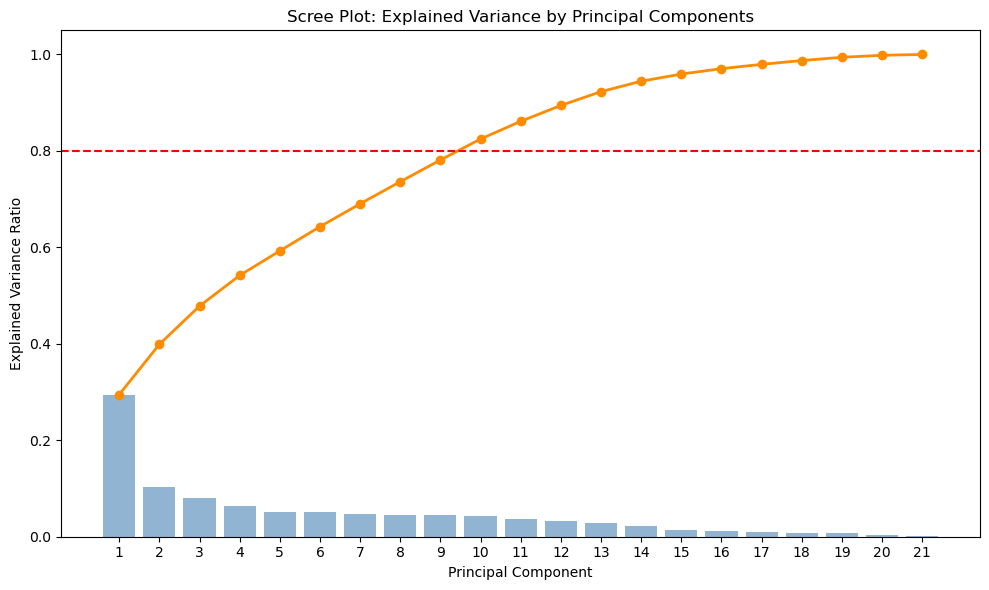

In [ ]:
var_ratio = pca.explained_variance_ratio_
cum_var_ratio = np.cumsum(var_ratio)
    
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(var_ratio) + 1), var_ratio, alpha=0.6, align='center',
        label='Individual explained variance', color='steelblue')
plt.plot(range(1, len(cum_var_ratio) + 1), cum_var_ratio, 
             label='Cumulative explained variance', color='darkorange', 
             linewidth=2, marker='o')
plt.axhline(y=0.8, color='red', linestyle='--', 
                    label=f'80% Variance Threshold')
plt.ylabel('Explained Variance')
plt.xlabel('Principal Component')
plt.title('Scree Plot: Explained Variance by Principal Components')
plt.xticks(range(1, len(var_ratio) + 1))
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

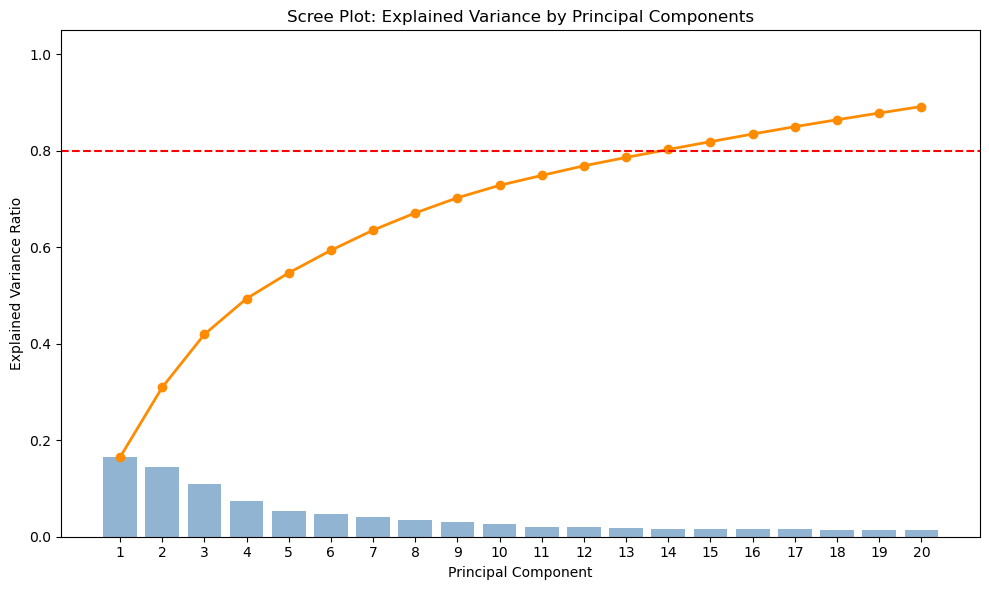

In [ ]:
var_ratio = pca_ratio.explained_variance_ratio_
cum_var_ratio = np.cumsum(var_ratio)
    
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(var_ratio) + 1), var_ratio, alpha=0.6, align='center',
        label='Individual explained variance', color='steelblue')
plt.plot(range(1, len(cum_var_ratio) + 1), cum_var_ratio, 
             label='Cumulative explained variance', color='darkorange', 
             linewidth=2, marker='o')
plt.axhline(y=0.8, color='red', linestyle='--', 
                    label=f'80% Variance Threshold')
plt.ylabel('Explained Variance')
plt.xlabel('Principal Component')
plt.title('Scree Plot: Explained Variance by Principal Components')
plt.xticks(range(1, len(var_ratio) + 1))
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

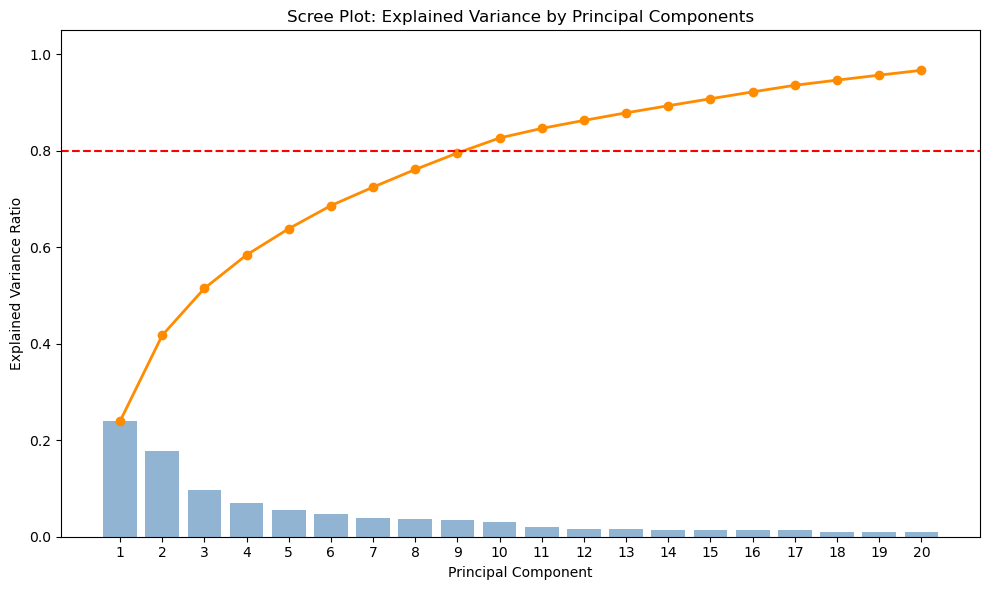

In [ ]:
var_ratio = log_pca.explained_variance_ratio_
cum_var_ratio = np.cumsum(var_ratio)
    
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(var_ratio) + 1), var_ratio, alpha=0.6, align='center',
        label='Individual explained variance', color='steelblue')
plt.plot(range(1, len(cum_var_ratio) + 1), cum_var_ratio, 
             label='Cumulative explained variance', color='darkorange', 
             linewidth=2, marker='o')
plt.axhline(y=0.8, color='red', linestyle='--', 
                    label=f'80% Variance Threshold')
plt.ylabel('Explained Variance')
plt.xlabel('Principal Component')
plt.title('Scree Plot: Explained Variance by Principal Components')
plt.xticks(range(1, len(var_ratio) + 1))
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()